In [5]:
import numpy as np
import tifffile
import torch
from pathlib import Path
import matplotlib.pyplot as plt
from skimage.measure import regionprops

RAW_DIR = Path("/QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant")
MASK_DIR = Path.home() / "cellpose_masks_resonant"

raw_files = sorted([f for f in RAW_DIR.glob("*.tif") if not f.name.startswith(".")] +
                   [f for f in RAW_DIR.glob("*.tiff") if not f.name.startswith(".")])

print("Raw files:", len(raw_files))
print("Example:", raw_files[0])

Raw files: 22
Example: /QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant/614399S2D20250113.tif


In [6]:
from segment_anything import sam_model_registry, SamPredictor

CKPT_PATH = Path.home() / "sam_checkpoints" / "sam_vit_b_01ec64.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint=str(CKPT_PATH))
sam.to(device=device)
predictor = SamPredictor(sam)

print("SAM ready on", device)

SAM ready on cuda


In [7]:
raw_fp = raw_files[0]
mask_fp = MASK_DIR / f"{raw_fp.stem}_masks.tif"

print("RAW:", raw_fp.name)
print("MASK exists:", mask_fp.exists(), mask_fp.name)

# Read only one 2D frame (page 0) 
with tifffile.TiffFile(raw_fp) as tif:
    frame0 = tif.pages[0].asarray()
    print("Num pages:", len(tif.pages))
    print("Frame0 shape:", frame0.shape, "dtype:", frame0.dtype)

cp_masks = tifffile.imread(mask_fp)
print("Mask shape:", cp_masks.shape, "dtype:", cp_masks.dtype, "labels:", int(cp_masks.max()))

RAW: 614399S2D20250113.tif
MASK exists: True 614399S2D20250113_masks.tif
Num pages: 1
Frame0 shape: (512, 512) dtype: uint16
Mask shape: (512, 512) dtype: uint16 labels: 21


NameError: name 'CELLPOSE_MASK_DIR' is not defined

In [9]:
import numpy as np

# convert frame to normalized float
im2d = frame0.astype(np.float32)
im2d = (im2d - im2d.min()) / (im2d.max() - im2d.min() + 1e-8)

# convert to RGB uint8 for SAM
rgb = np.repeat((im2d * 255).astype(np.uint8)[..., None], 3, axis=-1)

print("RGB image ready:", rgb.shape, rgb.dtype)

RGB image ready: (512, 512, 3) uint8


In [10]:
from segment_anything import sam_model_registry, SamPredictor
from pathlib import Path
import torch
import numpy as np

CKPT_PATH = Path.home() / "sam_checkpoints" / "sam_vit_b_01ec64.pth"

sam_cpu = sam_model_registry["vit_b"](checkpoint=str(CKPT_PATH))
sam_cpu.to(device="cpu")
predictor_cpu = SamPredictor(sam_cpu)

with torch.inference_mode():
    predictor_cpu.set_image(rgb)

print("CPU SAM embedding done")

CPU SAM embedding done


In [11]:
#pick one cellpose ROI 
from skimage.measure import regionprops
import numpy as np

props = regionprops(cp_masks)
print("Total ROIs:", len(props), "max label:", int(cp_masks.max()))

# pick a reasonably large ROI (avoid tiny noise)
props_sorted = sorted(props, key=lambda p: p.area, reverse=True)
roi = props_sorted[5]   # change 0.. to try different cells

lab = roi.label
print("Chosen label:", lab, "area:", roi.area)

cp_roi = (cp_masks == lab)

Total ROIs: 21 max label: 21
Chosen label: 6 area: 2645.0


In [12]:
#building a SAM prompt 
H, W = cp_masks.shape
box_expand = 6

minr, minc, maxr, maxc = roi.bbox
minr = max(0, minr - box_expand)
minc = max(0, minc - box_expand)
maxr = min(H, maxr + box_expand)
maxc = min(W, maxc + box_expand)

box = np.array([minc, minr, maxc, maxr], dtype=np.float32)  # XYXY

cy, cx = roi.centroid
point_coords = np.array([[cx, cy]], dtype=np.float32)
point_labels = np.array([1], dtype=np.int32)

print("Box:", box)
print("Centroid:", (cx, cy))

Box: [ 20. 140.  86. 224.]
Centroid: (np.float64(50.927788279773154), np.float64(179.2710775047259))


In [13]:
import torch

with torch.inference_mode():
    masks, scores, _ = predictor_cpu.predict(
        box=box[None, :],
        point_coords=point_coords,
        point_labels=point_labels,
        multimask_output=True   # we will choose best score
    )

best_i = int(np.argmax(scores))
sam_roi = masks[best_i]

print("SAM candidates:", masks.shape, "scores:", scores)
print("Chosen mask index:", best_i, "pixels:", int(sam_roi.sum()))

SAM candidates: (3, 512, 512) scores: [0.9197581  0.9356951  0.92918074]
Chosen mask index: 1 pixels: 2310


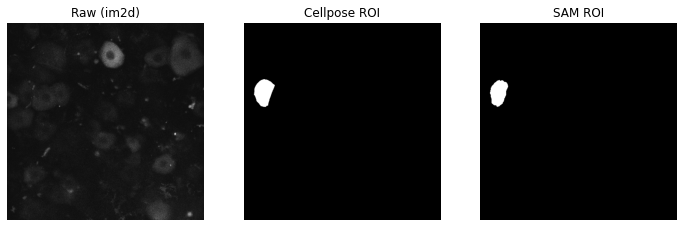

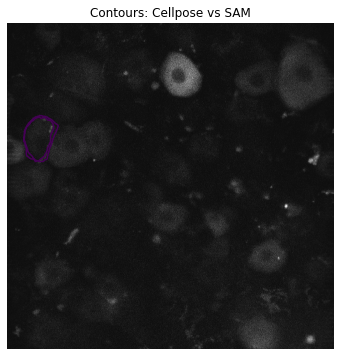

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Raw (im2d)"); plt.imshow(im2d, cmap="gray"); plt.axis("off")
plt.subplot(1,3,2); plt.title("Cellpose ROI"); plt.imshow(cp_roi, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("SAM ROI"); plt.imshow(sam_roi, cmap="gray"); plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(im2d, cmap="gray")
plt.contour(cp_roi.astype(float), levels=[0.5])
plt.contour(sam_roi.astype(float), levels=[0.5])
plt.title("Contours: Cellpose vs SAM")
plt.axis("off")
plt.show()

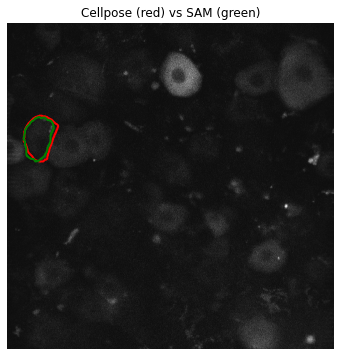

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(im2d, cmap="gray")

# Cellpose outline
plt.contour(cp_roi.astype(float), levels=[0.5], colors="red", linewidths=2)

# SAM outline
plt.contour(sam_roi.astype(float), levels=[0.5], colors="green", linewidths=2)

plt.title("Cellpose (red) vs SAM (green)")
plt.axis("off")

plt.show()

NameError: name 'regionprops' is not defined

NameError: name 'plt' is not defined